# Data mining, DPM

## HSE, 2025-26

# Data Extraction via Kaggle API

In [ ]:
import os
import kagglehub


os.environ['KAGGLE_USERNAME'] = ""
os.environ['KAGGLE_KEY'] = ""

!kaggle datasets files ealtman2019/ibm-transactions-for-anti-money-laundering-aml

name                           size  creationDate                
----------------------  -----------  --------------------------  
HI-Large_Patterns.txt      13807473  2025-07-08 14:59:17.308000  
HI-Large_Trans.csv      17052760651  2025-07-08 15:06:31.525000  
HI-Large_accounts.csv     147691860  2025-07-08 15:02:22.142000  
HI-Medium_Patterns.txt      2279574  2025-07-08 14:59:17.338000  
HI-Medium_Trans.csv      3031783420  2025-07-08 15:03:07.115000  
HI-Medium_accounts.csv    145008642  2025-07-08 15:02:23.558000  
HI-Small_Patterns.txt        323844  2025-07-08 14:59:17.159000  
HI-Small_Trans.csv        475664283  2025-07-08 15:02:26.907000  
HI-Small_accounts.csv      34053187  2025-07-08 15:02:20.682000  
LI-Large_Patterns.txt       1934790  2025-07-08 14:59:17.183000  
LI-Large_Trans.csv      16742513790  2025-07-08 15:06:48.925000  
LI-Large_accounts.csv     144349585  2025-07-08 15:02:22.283000  
LI-Medium_Patterns.txt       390893  2025-07-08 14:59:17.345000  
LI-Medium_

In [ ]:
files_to_download = [
    "HI-Small_Trans.csv",
    "HI-Small_accounts.csv",
    "LI-Small_Trans.csv",
    "LI-Small_accounts.csv"
]

for f in files_to_download:
    !kaggle datasets download -d ealtman2019/ibm-transactions-for-anti-money-laundering-aml -f {f}

Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0
HI-Small_Trans.csv: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0
HI-Small_accounts.csv: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0
LI-Small_Trans.csv: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0

In [ ]:
!ls -lh
#проверяем наличие файлов

total 1.2G
-rw-r--r-- 1 root root  33M Jul  8  2025 HI-Small_accounts.csv
-rw-r--r-- 1 root root 454M Jul  8  2025 HI-Small_Trans.csv
-rw-r--r-- 1 root root  46M Jul  8  2025 LI-Small_accounts.csv
-rw-r--r-- 1 root root 621M Jul  8  2025 LI-Small_Trans.csv
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data


Let's find out the number of strigs each of our datasets have

In [ ]:
!wc -l *.csv

    518582 HI-Small_accounts.csv
   5078346 HI-Small_Trans.csv
    712689 LI-Small_accounts.csv
   6924050 LI-Small_Trans.csv
  13233667 total


# Data Preparation (3% fraud)

In [ ]:
import pandas as pd

def get_precise_dataset(target_total=300000, fraud_rate=0.03):
    target_fraud = int(target_total * fraud_rate)
    target_normal = target_total - target_fraud

    frauds = []
    normals = []

    files = ['HI-Small_Trans.csv', 'LI-Small_Trans.csv']

    for file in files:
        for chunk in pd.read_csv(file, chunksize=300000):
            #Собираем преступные транзакции
            chunk_fraud = chunk[chunk['Is Laundering'] == 1]

            if len(pd.concat(frauds + [chunk_fraud])) <= target_fraud:
                frauds.append(chunk_fraud)
            else:
                needed = target_fraud - sum(len(f) for f in frauds)
                frauds.append(chunk_fraud.iloc[:needed]) #берем по количеству строки до needed, чтобы добрать сумму

            #Собираем обычные транзакции
            chunk_normal = chunk[chunk['Is Laundering'] == 0]
            if len(pd.concat(normals + [chunk_normal])) <= target_normal:
                normals.append(chunk_normal)
            else:
                needed = target_normal - sum(len(n) for n in normals)
                normals.append(chunk_normal.iloc[:needed])

            #Проверяем, набрали ли мы достаточно
            current_fraud_count = sum(len(f) for f in frauds)
            current_normal_count = sum(len(n) for n in normals)

            if current_fraud_count >= target_fraud and current_normal_count >= target_normal:
                break
        if current_fraud_count >= target_fraud and current_normal_count >= target_normal:
            break

    df_trans = pd.concat(frauds + normals)

    #Загружаем банковские аккаунты для склейки (объединяем справочники HI и LI вертикально)
    acc_hi = pd.read_csv('HI-Small_accounts.csv')
    acc_li = pd.read_csv('LI-Small_accounts.csv')
    df_acc = pd.concat([acc_hi, acc_li]).drop_duplicates(subset=['Bank ID', 'Account Number'])

    #Мерджим с аккаунтами
    df_final = pd.merge(
        df_trans, df_acc,
        left_on=['From Bank', 'Account'],
        right_on=['Bank ID', 'Account Number'],
        how='left'
    )

    #Чистим дубликаты колонок
    df_final = df_final.drop(columns=['Bank ID', 'Account Number'])
    #Перемешиваем данные, чтобы они не были по порядку фрод/нормал, и перемешанные индексы также возвращаем в нормальный вид
    df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

    return df_final

df = get_precise_dataset()

#Смотрим, сколько получилось каких данных
print("Итоговая статистика:")
print(df['Is Laundering'].value_counts())
print(f"Доля отмывания: {df['Is Laundering'].mean():.2%}")

Итоговая статистика:
Is Laundering
0    291000
1      8742
Name: count, dtype: int64
Доля отмывания: 2.92%


Ultimately, we received a bit less than 3%. Actually, we even tried to get 5% of fraud transcations (15k out of 300k), however, our small dataset of 13M strings simply lacks that amound of fraud data. So, we stopped at this number, which, we believe, is enough to train the models

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299742 entries, 0 to 299741
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Timestamp           299742 non-null  object 
 1   From Bank           299742 non-null  int64  
 2   Account             299742 non-null  object 
 3   To Bank             299742 non-null  int64  
 4   Account.1           299742 non-null  object 
 5   Amount Received     299742 non-null  float64
 6   Receiving Currency  299742 non-null  object 
 7   Amount Paid         299742 non-null  float64
 8   Payment Currency    299742 non-null  object 
 9   Payment Format      299742 non-null  object 
 10  Is Laundering       299742 non-null  int64  
 11  Bank Name           299742 non-null  object 
 12  Entity ID           299742 non-null  object 
 13  Entity Name         299742 non-null  object 
dtypes: float64(2), int64(3), object(9)
memory usage: 32.0+ MB


#EDA
###The most popular way of money laundering

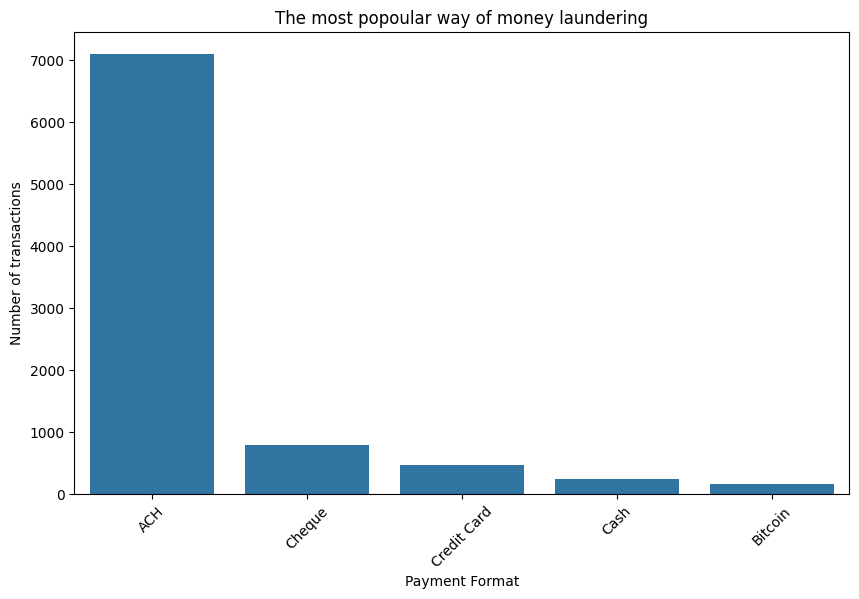

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fraud_df = df[df['Is Laundering'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(data=fraud_df, x='Payment Format', order=fraud_df['Payment Format'].value_counts().index)

plt.title('The most popoular way of money laundering')
plt.xlabel('Payment Format')
plt.ylabel('Number of transactions')
plt.xticks(rotation=45)
plt.show()

###Fraud Rate
We can see that ACH currently leads in terms of volume. But it’s important for us to understand: is this because ACH is inherently suspicious, or simply because ACH transfers are, by far, the most common type of transfer in the world? To find out, we need to plot a relative risk graph (showing the proportion of money laundering within each type).

*ACH (Automated Clearing House) is one of the most popular methods of transferring money in the United States. To draw an analogy with Russia, it is something between a standard bank transfer using account details (account number and BIC) and direct debit (when we authorize a utility company to automatically deduct money from our card).*

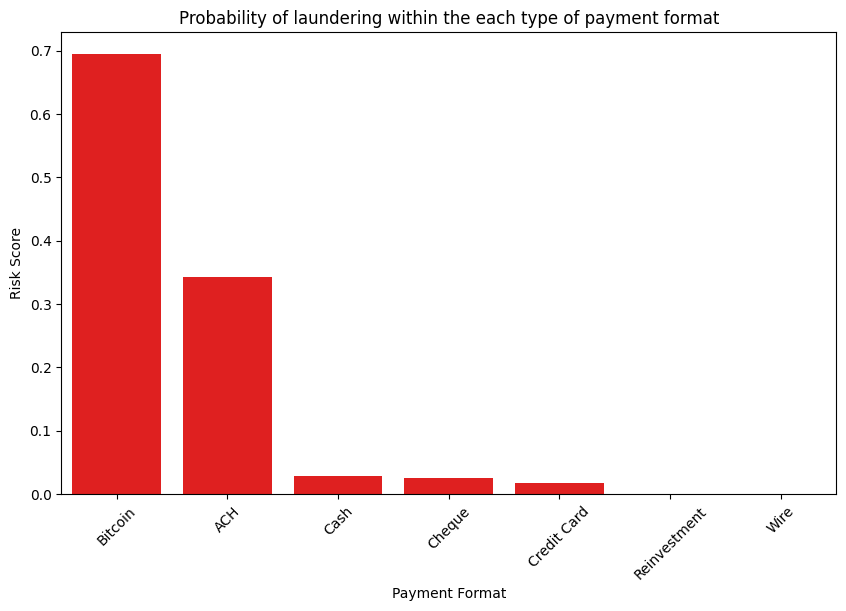

In [ ]:
plt.figure(figsize=(10, 6))

#группируем по формату и считаем среднее от Is Laundering (это и есть доля единиц тк у нас только 0/1)
risk_df = df.groupby('Payment Format')['Is Laundering'].mean().sort_values(ascending=False)

sns.barplot(x=risk_df.index, y=risk_df.values, color='r')
plt.title('Probability of laundering within the each type of payment format')
plt.ylabel('Risk Score')
plt.xticks(rotation=45)
plt.show()

The analysis revealed a strong correlation between payment method and the likelihood of money laundering. Bitcoin is the highest-risk instrument (fraud rate of 70%), while ACH is the primary channel in terms of the volume of criminal transactions (fraud rate of 35%). This confirms the hypothesis that the type of payment method will be one of the key features when training models.

##Transaction Amounts
We want to understand whether the amounts of ordinary transfers differ from those of criminal transfers. Typically, “dirty” money is either very large or, conversely, broken down into small amounts.

An analysis of the distribution of amounts below showed that suspicious transactions have a higher median and lower variability in the range of very small amounts. This means that the amount received feature will as well carry significant weight in the model, especially for filtering out micropayments.

/tmp/ipykernel_12748/2080370263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is Laundering', y='Amount Received', data=df, palette='Set1')


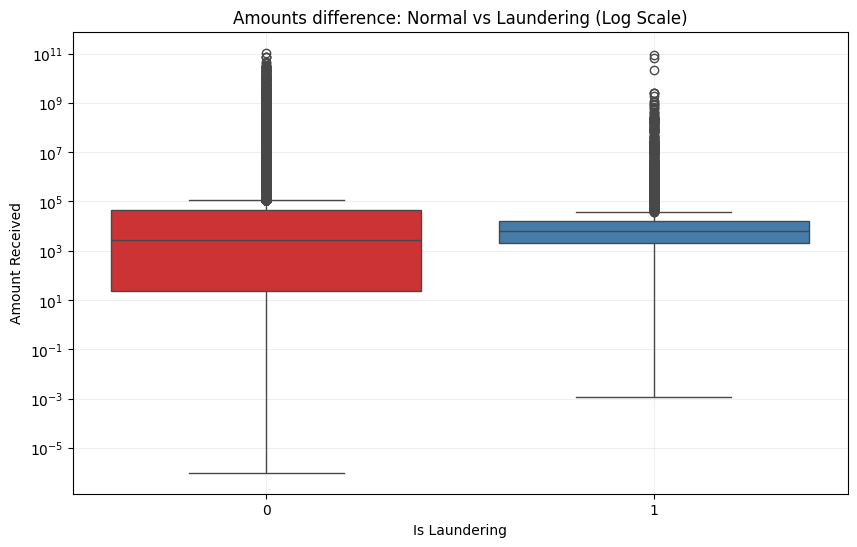

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is Laundering', y='Amount Received', data=df, palette='Set1')
plt.yscale('log') # Обязательно логарифмическая шкала, иначе выбросы все испортят, а мы фокусируем внимание на порядке величины
#нам неважно, это $501 или $502. Нам важно, это $500 или $50к
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.title('Amounts difference: Normal vs Laundering (Log Scale)')
plt.show()

1) The median at the right-hand box is higher than in the left-hand box. That means, on average, money laundering transactions involve larger amounts than regular transfers.

2) The height of the box itself (interquartile range) on the left side extends far downward. This means that ordinary people often transfer very small amounts.
As a small conclusion here - criminals rarely bother with $1 transactions. They have a “minimum threshold” for entering the scheme. They try to keep amounts within a certain range (roughly from 10^3 to 10^5).

3) Outliersin criminals have several points that go beyond the 10^11 threshold (that’s billions). So, the largest transfers in our dataset are almost certainly money laundering.

##Density of the distribution of sums (comparison)

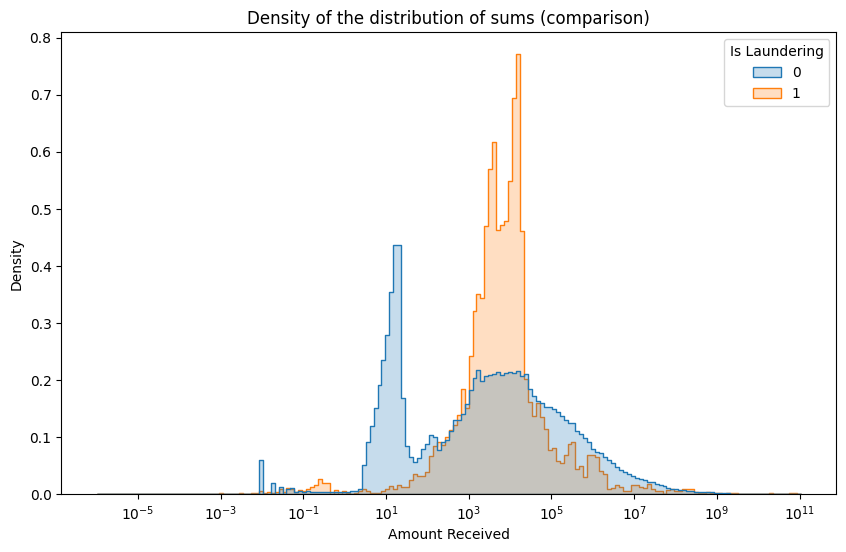

In [ ]:
plt.figure(figsize=(10, 6))
# Сравниваем распределение сумм (и тож используем логарифм сразу внутри графика)
sns.histplot(data=df, x='Amount Received', hue='Is Laundering', element="step", stat="density", common_norm=False, log_scale=True)

plt.title('Density of the distribution of sums (comparison)')
plt.show()

##Time of the day
Criminals often automate transfers or try to make them when bank security teams are less active (at night or on weekends).

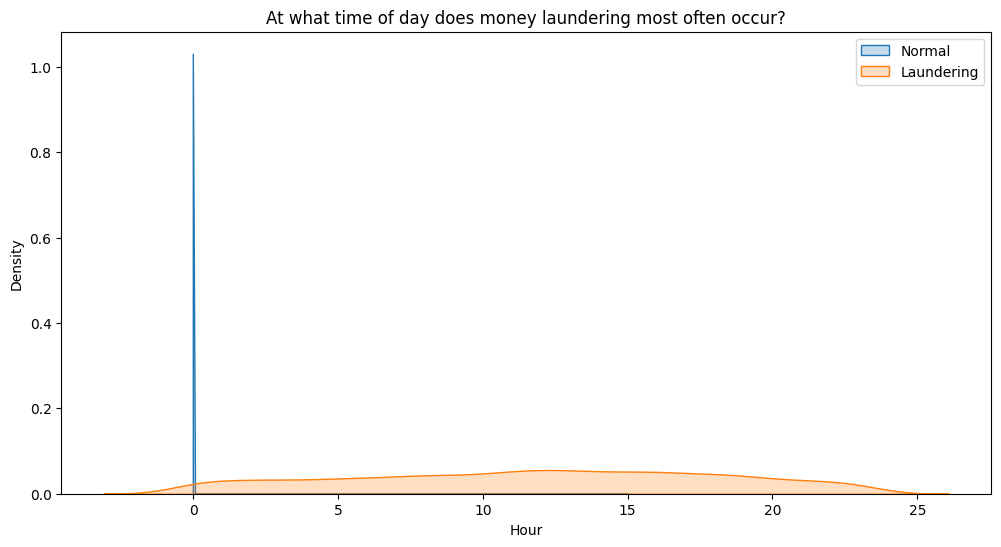

In [ ]:
#Превращаем Timestamp в формат даты и вытаскиваем час
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['Is Laundering'] == 0], x='Hour', label='Normal', fill=True)
sns.kdeplot(data=df[df['Is Laundering'] == 1], x='Hour', label='Laundering', fill=True)
plt.title('At what time of day does money laundering most often occur?')
plt.legend()
plt.show()

In [ ]:
#Видим треш. Посмотрим, какие вообще часы встречаются у обычных и у преступников
print("Timestamp normal (top 5):")
print(df[df['Is Laundering'] == 0]['Hour'].value_counts().head())

print("Часы у отмывания (топ-5):")
print(df[df['Is Laundering'] == 1]['Hour'].value_counts().head())

Timestamp normal (top 5):
Hour
0     290994
15         2
9          2
14         1
4          1
Name: count, dtype: int64
Часы у отмывания (топ-5):
Hour
12    519
16    487
13    477
11    471
14    456
Name: count, dtype: int64


An anomaly was detected when analyzing the “Timestamp” feature: 99% of normal transactions have a timestamp of 00:00. This is a characteristic of the synthetic dataset generation process. To prevent the model from learning a false correlation (time-based overfitting), this feature was excluded from the training of the base models. Moreover, in real-world anti-money laundering (AML) scenarios, the timing is often less important than the structure of the transaction: **who, to whom, and how much**

## Entity Analysis
Let's see who is more likely to be involved in the criminal schemes: corporations or individuals.

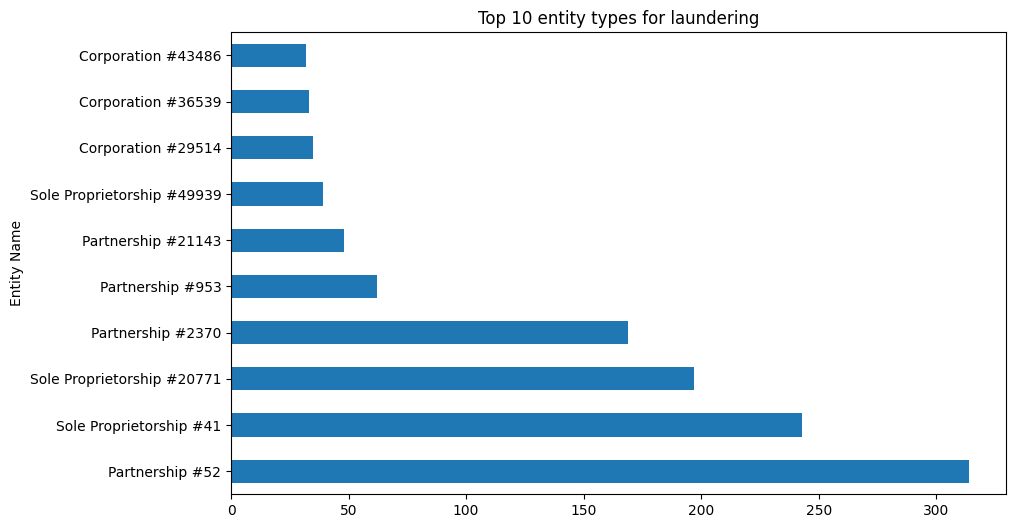

In [ ]:
plt.figure(figsize=(10, 6))
fraud_df['Entity Name'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 entity types for laundering')
plt.show()

#Data Preprocessing




### Entity Type

In [ ]:
#Убираем номера и лишние символы из Entity Name
df['Entity Type'] = df['Entity Name'].str.replace(r'\s*#\d+', '', regex=True).str.strip()

#Смотрим все уникальные типы
print('Sender-accounts in laundering schemas')
print(df['Entity Type'].value_counts())


Sender-accounts in laundering schemas
Entity Type
Partnership            106581
Sole Proprietorship     97386
Corporation             95119
Individual                533
Country                   119
Direct                      4
Name: count, dtype: int64


Entity Type
Country                0.260504
Individual             0.039400
Corporation            0.032328
Partnership            0.029020
Sole Proprietorship    0.025897
Direct                 0.000000
Name: Is Laundering, dtype: float64


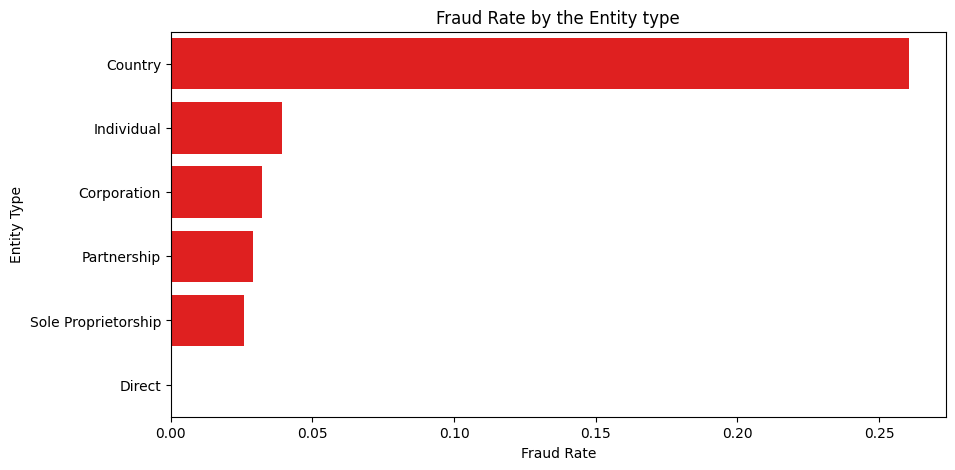

In [ ]:
#Fraud rate по типу сущности
fraud_rate = df.groupby('Entity Type')['Is Laundering'].mean().sort_values(ascending=False)
print(fraud_rate)

plt.figure(figsize=(10, 5))
sns.barplot(x=fraud_rate.values, y=fraud_rate.index, color='r')
plt.title('Fraud Rate by the Entity type')
plt.xlabel('Fraud Rate')
plt.show()

**What types of payments are hidden behind the term “Country”?**
This term typically refers to three main mechanisms that money launderers love to use:

1. Wire Transfer (international bank transfer)
This is a classic method. Money is transferred from a bank in one country to a bank in another.
Different countries have different laws. Criminals transfer money to countries with “soft” financial controls (offshore jurisdictions), where the bank won’t ask, “Where did you get that million?”

2. SWIFT payments
A global messaging system between banks.

3. Correspondent accounts
Large banks open accounts with each other in different countries. Criminals use long chains of such banks (“transit countries”) to cover their tracks. Money jumps from one place to another: Russia -> Latvia -> Cyprus -> British Virgin Islands. With each jump, it becomes increasingly difficult to trace the ultimate owner.

**AML systems include the concept of high-risk jurisdictions:**
1) Offshore jurisdictions: Panama, the Cayman Islands (which offer low taxes and a high degree of anonymity).

2) Countries under sanctions: Where oversight is difficult due to political reasons.

3) Transit hubs - countries with massive cash flows where funds can easily get lost (for example, certain financial hubs in Asia).

In [ ]:
print(df[df['Entity Type'] == 'Country']['Entity Name'].value_counts())
print(f"Total Country transactions: {(df['Entity Type'] == 'Country').sum()}")
print(f"Fraud out of them: {df[df['Entity Type'] == 'Country']['Is Laundering'].sum()}")
print('\n')
print(df[df['Entity Type'] == 'Direct']['Entity Name'].value_counts())
print(f"Total Direct transactions: {(df['Entity Type'] == 'Direct').sum()}")
print(f"Fraud out of them: {df[df['Entity Type'] == 'Direct']['Is Laundering'].sum()}")

Entity Name
Country #1    103
Country #2     16
Name: count, dtype: int64
Total Country transactions: 119
Fraud out of them: 31


Entity Name
Direct #1    2
Direct #2    2
Name: count, dtype: int64
Total Direct transactions: 4
Fraud out of them: 0


We are combining “Country” and ‘Direct’ into a single “Other” subgroup, since the total number of transactions for these categories is very low

In [ ]:
df['Entity Type'] = df['Entity Type'].replace({
    'Country': 'Other',
    'Direct': 'Other'
})

## Timestamp

We’re checking to see if there’s any meaningful data by day of the week. There’s no data by hour (most transactions occur at midnight). By day of the week, most transactions also occur on Wednesdays -> we can exclude the timestamp from further analysis because, since the dataset is synthetic, there are no real influencing factors.

In [ ]:
print(df['Timestamp'].dt.dayofweek.value_counts())

Timestamp
3    292604
4      1671
5      1443
1      1046
0      1038
6       987
2       953
Name: count, dtype: int64


## Bank Name

In [ ]:
print(df['Bank Name'].value_counts().head(10))
print(f"Unique names: {df['Bank Name'].nunique()}")

Bank Name
Oasis Thrift                 6365
National Bank of Laramie     3497
National Bank of the East    3265
Arbor Savings Bank           2731
Japan Bank #0                1961
Savings Bank of Fairfield    1929
First Bank of Tampa          1878
Golden Bancorp               1778
Savings Bank of Huron        1761
China Bank #14               1605
Name: count, dtype: int64
Unique names: 9131


We want to analyze the relationship between bank IDs and their human-readable names. Specifically, we count the unique occurrences of both and display a mapping table to verify if each ID consistently corresponds to a single bank name.

We can see that 'From Bank' exceeds 'Bank Name'. A single bank (with a single name) may have multiple unique identifiers for its divisions, branches, or clearing centers.

Example: “Bank of America” has a single name, but it may have 50 different IDs for different regions.

In [ ]:
print(f"Unique names Bank Name: {df['Bank Name'].nunique()}")
print(f"Unique names From Bank: {df['From Bank'].nunique()}")
print("Bank Name examples:")
print(df[['From Bank', 'Bank Name']].drop_duplicates().head(20))

Unique names Bank Name: 9131
Unique names From Bank: 14627
Bank Name examples:
    From Bank                     Bank Name
0       26463             Germany Bank #286
1      125164             Ireland Bank #324
2       28693       National Bank of Albany
3       12719           Bank of New Orleans
4       21918              Belgium Bank #87
5       13037        First Bank of Hartford
6       27621            Australia Bank #20
7      317948            Germany Bank #2643
8        5175              Germany Bank #59
9        7478         Savings Bank of Huron
10         19             Australia Bank #3
11     246894               Italy Bank #577
12        513  National Bank of New Orleans
13     348250    National Bank of the South
14      17649               Spain Bank #992
15     322842               China Bank #356
16     137335            Heath Federal Bank
17     346750            Oasis Savings Bank
18     125607               Canada Bank #35
19     137218          Switzerland Bank #

**Finding Shell Banks**

We are identifying 'high-risk entities' by calculating the fraud rate per bank. By filtering for banks where more than 50% of transactions are fraudulent (with a minimum of 10 operations), we isolate systemic money laundering hubs rather than isolated incidents

In [ ]:
#Fraud rate по From Bank
bank_fraud = df.groupby('From Bank')['Is Laundering'].agg(['mean', 'count'])
print("Banks with fraud rate > 50% и >10 транзакций:")
print(bank_fraud[(bank_fraud['mean'] > 0.5) & (bank_fraud['count'] > 10)].sort_values('mean', ascending=False).head(10))

#Fraud rate по Bank Name (сгруппированный)
print(f"\nUnique From Bank: {df['From Bank'].nunique()}")
print(f"Unique Bank Name: {df['Bank Name'].nunique()}")

Banks with fraud rate > 50% и >10 транзакций:
           mean  count
From Bank             
0           1.0     25
18          1.0     11
119         1.0     59
121         1.0     19
222         1.0     33
223         1.0     35
224         1.0     34
349         1.0     23
394         1.0     22
423         1.0     28

Unique From Bank: 14627
Unique Bank Name: 9131


   From Bank                    Bank Name  Fraud Rate  Transaction Count
0         11      Savings Bank of Madison    1.000000                 83
1         12    National Bank of Columbus    1.000000                 64
2         20        First Bank of Danbury    1.000000                 78
3        119               Israel Bank #6    1.000000                 59
4         70               Willows Thrift    1.000000                850
5     135981  National Bank of Harrisburg    0.254545                 55
6     214749               India Bank #43    0.190476                 84
7     231212        Netherlands Bank #500    0.182927                 82
8     213952      Savings Bank of Houston    0.143478                230
9      11128               Japan Bank #52    0.142857                 98


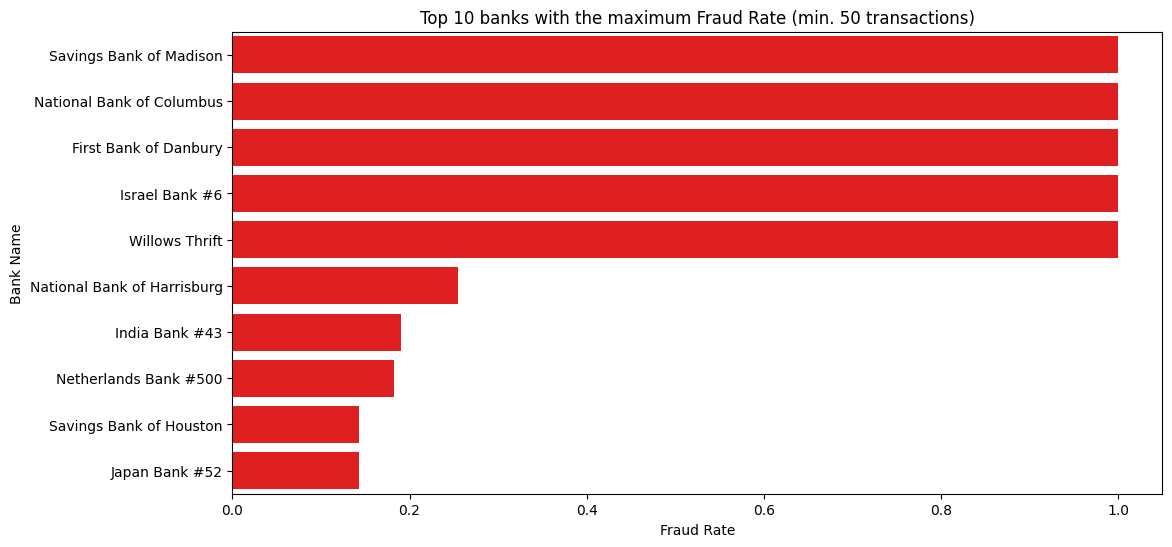

In [ ]:
bank_fraud = df.groupby(['From Bank', 'Bank Name'])['Is Laundering'].agg(['mean', 'count']).reset_index()
bank_fraud.columns = ['From Bank', 'Bank Name', 'Fraud Rate', 'Transaction Count']

top_criminal_banks = (bank_fraud[bank_fraud['Transaction Count'] > 50]
                      .sort_values('Fraud Rate', ascending=False)
                      .head(10)
                      .reset_index(drop=True))

print(top_criminal_banks)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_criminal_banks,
    x='Fraud Rate',
    y='Bank Name',
    color='r',
    legend=False
)
plt.title('Top 10 banks with the maximum Fraud Rate (min. 50 transactions)')
plt.xlabel('Fraud Rate')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Train/test индексы (те же random_state и stratify, что в финальном split) —
# агрегаты по банку считаем только на train, без утечки меток test.
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.2,
    random_state=67,
    stratify=df['Is Laundering'],
)
train_sub = df.loc[idx_train]
global_fraud = train_sub['Is Laundering'].mean()

# Насколько криминален банк-отправитель
sender_rate = train_sub.groupby('From Bank')['Is Laundering'].mean()
sender_cnt = train_sub.groupby('From Bank').size()
df['sender_bank_fraud_rate'] = df['From Bank'].map(sender_rate).fillna(global_fraud)
df['sender_bank_count'] = df['From Bank'].map(sender_cnt).fillna(0)

# Насколько криминален банк-получатель
receiver_rate = train_sub.groupby('To Bank')['Is Laundering'].mean()
receiver_cnt = train_sub.groupby('To Bank').size()
df['receiver_bank_fraud_rate'] = df['To Bank'].map(receiver_rate).fillna(global_fraud)
df['receiver_bank_count'] = df['To Bank'].map(receiver_cnt).fillna(0)

df[['sender_bank_fraud_rate', 'sender_bank_count','receiver_bank_fraud_rate', 'receiver_bank_count']]

,sender_bank_fraud_rate,sender_bank_count,receiver_bank_fraud_rate,receiver_bank_count
0,0.005525,181.0,0.010695,187.0
1,0.013158,76.0,0.009524,105.0
2,0.010363,193.0,0.013825,217.0
3,0.013889,360.0,0.014837,337.0
4,0.025424,354.0,0.014218,211.0
...,...,...,...,...
299737,0.000000,66.0,0.000000,81.0
299738,0.020576,243.0,0.004098,244.0
299739,0.088722,1330.0,0.122449,1127.0
299740,0.015464,194.0,0.018433,217.0


## Account
Now we are looking for specific accounts (wallets) that were created solely for criminal purposes.

In [ ]:
print(f"Уникальных Account (отправитель): {df['Account'].nunique()}")
print(f"Уникальных Account.1 (получатель): {df['Account.1'].nunique()}")
print(f"Всего строк: {len(df)}")

# Fraud rate по аккаунтам — есть ли аккаунты которые всегда мошенничают?
account_fraud = df.groupby('Account')['Is Laundering'].agg(['mean', 'count'])
print("Аккаунты с fraud rate = 100% и >5 транзакций:")
print(account_fraud[(account_fraud['mean'] == 1.0) & (account_fraud['count'] > 5)])

Уникальных Account (отправитель): 221283
Уникальных Account.1 (получатель): 215507
Всего строк: 299742
Аккаунты с fraud rate = 100% и >5 транзакций:
           mean  count
Account               
1004289C0   1.0     13
100428A08   1.0     13
100428A51   1.0     18
10042B660   1.0    314
10042B6A8   1.0    196
...         ...    ...
812A09D40   1.0     18
812A70ED0   1.0     10
812D0C3C0   1.0     17
812D0C600   1.0     10
812D22980   1.0     25

[105 rows x 2 columns]


So, on average, there are 1–2 transactions, but there are accounts that are 100% fraudulent and yet show increased activity.

The analysis successfully identified 105 dedicated fraudulent accounts with a 100% laundering rate. The discovery of high-volume hubs (e.g., account 10042B660 with 314 illicit transactions) provides empirical evidence of a structured criminal network. These accounts act as 'money laundering engines,' making their IDs highly predictive features for our future classification model.

In [ ]:
# Признаки по аккаунту-отправителю
df['sender_count'] = df.groupby('Account')['Account'].transform('count')
df['sender_avg_amount'] = df.groupby('Account')['Amount Paid'].transform('mean')
df['sender_unique_recipients'] = df.groupby('Account')['To Bank'].transform('nunique')

# Признаки по аккаунту-получателю
df['receiver_count'] = df.groupby('Account.1')['Account.1'].transform('count')
df['receiver_avg_amount'] = df.groupby('Account.1')['Amount Received'].transform('mean')
df['receiver_unique_senders'] = df.groupby('Account.1')['From Bank'].transform('nunique')
df[['sender_count','sender_avg_amount', 'sender_unique_recipients',  'receiver_count', 'receiver_avg_amount', 'receiver_unique_senders']]


,sender_count,sender_avg_amount,sender_unique_recipients,receiver_count,receiver_avg_amount,receiver_unique_senders
0,1,17.540,1,2,2.220845e+03,2
1,1,138.470,1,1,1.384700e+02,1
2,1,67383.520,1,1,6.738352e+04,1
3,2,1170.455,1,2,1.170455e+03,1
4,5,1643258.806,2,4,2.041707e+06,1
...,...,...,...,...,...,...
299737,1,19.560,1,1,1.956000e+01,1
299738,1,4.210,1,1,4.210000e+00,1
299739,1,8.970,1,1,8.970000e+00,1
299740,5,12346.892,2,2,1.175349e+04,1


## Removing unnecessary columns

In [ ]:
# Сырые ID убираем, агрегированные признаки уже созданы выше
cols_to_drop = ['Account', 'Account.1', 'Entity ID', 'Entity Name',
                'Bank Name', 'Timestamp', 'From Bank', 'To Bank', 'Hour']

# 'Account', 'Account.1' - ID аккаунтов не нужны для для обучения модели, их заменили на
# sender_count, sender_avg_amount, sender_unique_recipients, receiver_count, receiver_avg_amount, receiver_unique_senders
# 'Entity ID', 'Entity Name' - лишние, мы их заменили на Entity Type
# Bank Name - заменяем на признаки типо sender_bank_fraud_rate, sender_bank_count, receiver_bank_fraud_rate, receiver_bank_count


df_clean = df.drop(columns=cols_to_drop)
print(df_clean.columns.tolist())
print(df_clean.shape)

['Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'Entity Type', 'sender_bank_fraud_rate', 'sender_bank_count', 'receiver_bank_fraud_rate', 'receiver_bank_count', 'sender_count', 'sender_avg_amount', 'sender_unique_recipients', 'receiver_count', 'receiver_avg_amount', 'receiver_unique_senders']
(299742, 17)


## Erroneous values

"sanitarnaya proverka"

In [ ]:
# Отрицательные суммы
print("Negative sums:")
print((df_clean[['Amount Received', 'Amount Paid']] < 0).sum())

# Нулевые суммы
print("\nNull sums:")
print((df_clean[['Amount Received', 'Amount Paid']] == 0).sum())

# Пропуски
print("\nMissing values:")
print(df_clean.isnull().sum())

# Уникальные значения категориальных
print("\nUnique categorical features:")
for col in ['Receiving Currency', 'Payment Currency', 'Payment Format', 'Entity Type']:
    print(f"{col}: {df_clean[col].unique()}")

Negative sums:
Amount Received    0
Amount Paid        0
dtype: int64

Null sums:
Amount Received    0
Amount Paid        0
dtype: int64

Missing values:
Amount Received             0
Receiving Currency          0
Amount Paid                 0
Payment Currency            0
Payment Format              0
Is Laundering               0
Entity Type                 0
sender_bank_fraud_rate      0
sender_bank_count           0
receiver_bank_fraud_rate    0
receiver_bank_count         0
sender_count                0
sender_avg_amount           0
sender_unique_recipients    0
receiver_count              0
receiver_avg_amount         0
receiver_unique_senders     0
dtype: int64

Unique categorical features:
Receiving Currency: ['Euro' 'US Dollar' 'Australian Dollar' 'Canadian Dollar' 'Yuan'
 'Swiss Franc' 'Ruble' 'UK Pound' 'Yen' 'Brazil Real' 'Rupee'
 'Saudi Riyal' 'Mexican Peso' 'Bitcoin' 'Shekel']
Payment Currency: ['Euro' 'US Dollar' 'Australian Dollar' 'Canadian Dollar' 'Yuan'
 'Swiss Franc

## Encoding of Categorical Features

In [ ]:
df_encoded = pd.get_dummies(df_clean,
                            columns=['Receiving Currency', 'Payment Currency',
                                     'Payment Format', 'Entity Type'],
                            drop_first=True)  # убираем одну колонку чтобы избежать мультиколлинеарности

print(df_encoded.shape)
print(df_encoded.columns.tolist())
df_encoded

(299742, 51)
['Amount Received', 'Amount Paid', 'Is Laundering', 'sender_bank_fraud_rate', 'sender_bank_count', 'receiver_bank_fraud_rate', 'receiver_bank_count', 'sender_count', 'sender_avg_amount', 'sender_unique_recipients', 'receiver_count', 'receiver_avg_amount', 'receiver_unique_senders', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Currency_Rupee', 'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel', 'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound', 'Receiving Currency_US Dollar', 'Receiving Currency_Yen', 'Receiving Currency_Yuan', 'Payment Currency_Bitcoin', 'Payment Currency_Brazil Real', 'Payment Currency_Canadian Dollar', 'Payment Currency_Euro', 'Payment Currency_Mexican Peso', 'Payment Currency_Ruble', 'Payment Currency_Rupee', 'Payment Currency_Saudi Riyal', 'Payment Currency_Shekel', 'Payme

,Amount Received,Amount Paid,Is Laundering,sender_bank_fraud_rate,sender_bank_count,receiver_bank_fraud_rate,receiver_bank_count,sender_count,sender_avg_amount,sender_unique_recipients,...,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Entity Type_Individual,Entity Type_Other,Entity Type_Partnership,Entity Type_Sole Proprietorship
0,17.54,17.54,0,0.005525,181.0,0.010695,187.0,1,17.540,1,...,False,False,False,False,True,False,False,False,True,False
1,138.47,138.47,0,0.013158,76.0,0.009524,105.0,1,138.470,1,...,False,False,False,False,True,False,False,False,False,True
2,67383.52,67383.52,0,0.010363,193.0,0.013825,217.0,1,67383.520,1,...,False,False,False,False,True,False,False,False,True,False
3,8.62,8.62,0,0.013889,360.0,0.014837,337.0,2,1170.455,1,...,False,False,False,False,True,False,False,False,True,False
4,1921334.36,1921334.36,0,0.025424,354.0,0.014218,211.0,5,1643258.806,2,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299737,19.56,19.56,0,0.000000,66.0,0.000000,81.0,1,19.560,1,...,False,False,False,False,True,False,False,False,True,False
299738,4.21,4.21,0,0.020576,243.0,0.004098,244.0,1,4.210,1,...,False,False,False,False,True,False,False,False,False,False
299739,8.97,8.97,0,0.088722,1330.0,0.122449,1127.0,1,8.970,1,...,False,False,False,False,True,False,False,False,False,True
299740,16.34,16.34,0,0.015464,194.0,0.018433,217.0,5,12346.892,2,...,False,False,False,False,True,False,False,False,False,False


# Feature Engineering

### Train/test

In [ ]:
X = df_encoded.drop(columns=['Is Laundering'])
y = df_encoded['Is Laundering']

# Те же индексы, что при расчёте sender/receiver_bank...
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Fraud в train: {y_train.mean():.2%}")
print(f"Fraud в test: {y_test.mean():.2%}")

Train: (239793, 50), Test: (59949, 50)
Fraud в train: 2.92%
Fraud в test: 2.92%


In [ ]:
from sklearn.preprocessing import RobustScaler

# RobustScaler лучше StandardScaler для наших данных —
# он устойчив к выбросам, а у нас суммы транзакций сильно разбросаны
scaler = RobustScaler()

# Скейлим только числовые признаки
num_cols = ['Amount Received', 'Amount Paid', 'sender_bank_fraud_rate',
            'sender_bank_count', 'receiver_bank_fraud_rate', 'receiver_bank_count',
            'sender_count', 'sender_avg_amount', 'sender_unique_recipients',
            'receiver_count', 'receiver_avg_amount', 'receiver_unique_senders']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler.fit(X_train[num_cols])

X_train_scaled[num_cols] = scaler.transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(X_train_scaled[num_cols].describe().round(2))

       Amount Received  Amount Paid  sender_bank_fraud_rate  \
count        239793.00    239793.00               239793.00   
mean            199.78       179.91                    1.02   
std            9836.08      9097.83                    5.97   
min              -0.07        -0.07                   -0.72   
25%              -0.07        -0.07                   -0.46   
50%               0.00         0.00                    0.00   
75%               0.93         0.93                    0.54   
max         2399741.94   2397655.35                   59.11   

       sender_bank_count  receiver_bank_fraud_rate  receiver_bank_count  \
count          239793.00                 239793.00            239793.00   
mean                0.79                      0.91                 0.35   
std                 2.99                      6.33                 1.44   
min                -0.68                     -0.78                -0.89   
25%                -0.37                     -0.45       

In [ ]:
print("Min in initial data:")
print(X_train[['Amount Received', 'Amount Paid']].min())

print("Min after scaling:")
print(X_train_scaled[['Amount Received', 'Amount Paid']].min())

Min in initial data:
Amount Received    0.000001
Amount Paid        0.000001
dtype: float64
Min after scaling:
Amount Received   -0.065967
Amount Paid       -0.066107
dtype: float64


# Machine Learning

## Logistic regression

We will use the logistic regression model as a baseline for further evaluation. It looks for a hyperplane that separates classes by calculating the weighted sum of features and, through the sigmoid function, converts it into a fraud probability from 0 to 1.

Due to the imbalance of data in the dataset, we added the `class_weight='balanced'` parameter to prevent precision from being high and recall from being low. It automatically increases the penalty for missing a fraud transaction in proportion to the class imbalance. Thus, our model will pay more attention to rare classes



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import classification_report, f1_score, roc_auc_score

param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}

grid = HalvingGridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=67,
    ),
    param_grid,
    cv=3,
    scoring="recall",
    random_state=67,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train_scaled, y_train)
lr = grid.best_estimator_

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=["Legit", "Fraud"]))
# macro avg - простое среднее по классам, каждый класс важен одинаково
# weighted avg - среднее с учётом размера класса
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.4f}")


n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 79931
max_resources_: 239793
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 4
n_resources: 79931
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 239793
Fitting 3 folds for each of 2 candidates, totalling 6 fits
              precision    recall  f1-score   support

       Legit       1.00      0.93      0.96     58201
       Fraud       0.29      0.92      0.44      1748

    accuracy                           0.93     59949
   macro avg       0.64      0.93      0.70     59949
weighted avg       0.98      0.93      0.95     59949

ROC-AUC: 0.9772


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## KNN

KNN allows fraudulent transactions to be identified based on similarity: if a transaction resembles a fraudulent one, it is considered suspicious. The initial model yielded:


1.   precision: 0.93
2.   recall: 0.74
3.   F1-score: 0.82
4.   ROC-AUC: 0.9401

We optimised the model by increasing the number of `n_neighbours` from 5 to 11. This gives fraudulent transactions a better chance of receiving votes. We used an odd number to avoid a tie in the voting. We also set the model parameter `weights=“distance”` so that the vote of the nearest neighbour carries more weight than that of a distant one (by default, all neighbours vote equally).

Initially, the problem lay in the decision-making process at high precision; recall was 0.74.

To optimise the model after training, we added HalvingGridSearch

In our case, it is more important to increase recall than to maintain precision, because it is better to double-check a transaction than to miss a fraud.

Final optimized results:

1.   precision:  0.6344
2.   recall: 0.8330
3.   F1-score: 0.7203
4.   ROC-AUC: 0.9328

### Initial KNN model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1,        #используем все ядра процесса для увеличения скорости
    metric='euclidean'
)

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn, target_names=['Legit', 'Frad'])) #https://datafinder.ru/products/klassifikacionnyy-otchet-v-mashinnom-obuchenii
# macro avg - простое среднее по классам, каждый класс важен одинаково
# weighted avg - среднее с учётом размера класса
print(f"ROC-AUC: {roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]):.4f}") # поскольку knn.predict_proba возвращает двумерный массив, мы берем только второй стлобец - вероятность фрода

              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99     58201
        Frad       0.87      0.69      0.77      1748

    accuracy                           0.99     59949
   macro avg       0.93      0.84      0.88     59949
weighted avg       0.99      0.99      0.99     59949

ROC-AUC: 0.9294


### Optimized KNN using HalvingGridSearchCV

In [ ]:
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier(n_jobs=-1)

grid = HalvingGridSearchCV(
    knn,
    param_grid,
    cv=3,
    scoring='recall',
    random_state=67,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 26643
max_resources_: 239793
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 26643
Fitting 3 folds for each of 20 candidates, totalling 60 fits
----------
iter: 1
n_candidates: 7
n_resources: 79929
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 2
n_candidates: 3
n_resources: 239787
Fitting 3 folds for each of 3 candidates, totalling 9 fits


In [ ]:
from sklearn.metrics import recall_score

best_knn = grid.best_estimator_

y_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.01,0.5,0.01)

best_thr = 0
best_recall = 0

for t in thresholds:
    y_pred = (y_proba >=t).astype(int)
    recall = recall_score(y_test, y_pred)

    if recall > best_recall:
        best_recall = recall
        best_thr= t

print(best_thr, best_recall) # тут нет матрицы с метриками, потому что я забыла ее добавить, но она будет в финальной визуализации
# полный прогон кода очень долгий)) простите)))

0.01 0.8707093821510298


## Desicion Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

param_grid = {"max_depth": [8, 10, 15, 20], "min_samples_leaf": [5, 20, 50]}

grid = HalvingGridSearchCV(
    DecisionTreeClassifier(class_weight="balanced",random_state=67),
    param_grid,
    cv=3,
    scoring="recall",
    random_state=67,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train_scaled, y_train)
dt = grid.best_estimator_

y_pred_dt = dt.predict(X_test_scaled)
print(classification_report(y_test, y_pred_dt, target_names=["Legit", "Fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:, 1]):.4f}")


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 26643
max_resources_: 239793
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 12
n_resources: 26643
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 1
n_candidates: 4
n_resources: 79929
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 2
n_resources: 239787
Fitting 3 folds for each of 2 candidates, totalling 6 fits
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     58201
       Fraud       0.41      0.91      0.56      1748

    accuracy                           0.96     59949
   macro avg       0.70      0.93      0.77     59949
weighted avg       0.98      0.96      0.97     59949

ROC-AUC: 0.9448


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

param_grid = {"n_estimators": [50, 100], "max_depth": [10, 15, 20]}

grid = HalvingGridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        min_samples_leaf=10,
        random_state=67,
        n_jobs=-1,
    ),
    param_grid,
    cv=3,
    scoring="recall",
    random_state=67,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train_scaled, y_train)
rf = grid.best_estimator_

y_pred_rf = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf, target_names=["Legit", "Fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1]):.4f}")


n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 79931
max_resources_: 239793
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 6
n_resources: 79931
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 1
n_candidates: 2
n_resources: 239793
Fitting 3 folds for each of 2 candidates, totalling 6 fits
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     58201
       Fraud       0.55      0.92      0.69      1748

    accuracy                           0.98     59949
   macro avg       0.77      0.95      0.84     59949
weighted avg       0.98      0.98      0.98     59949

ROC-AUC: 0.9931


## CatBoost

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

w = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
param_grid = {"depth": [6,8, 10], "learning_rate": [0.03, 0.05]}

grid = HalvingGridSearchCV(
    CatBoostClassifier(
        iterations=300,
        scale_pos_weight=w,
        random_seed=67,
        verbose=False,
    ),
    param_grid,
    cv=3,
    scoring="recall",
    random_state=67,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train_scaled, y_train)
cb = grid.best_estimator_

y_pred_cb = cb.predict(X_test_scaled)
print(classification_report(y_test, y_pred_cb, target_names=["Legit", "Fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, cb.predict_proba(X_test_scaled)[:, 1]):.4f}")


n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 79931
max_resources_: 239793
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 6
n_resources: 79931
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 1
n_candidates: 2
n_resources: 239793
Fitting 3 folds for each of 2 candidates, totalling 6 fits
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     58201
       Fraud       0.61      0.94      0.74      1748

    accuracy                           0.98     59949
   macro avg       0.81      0.96      0.87     59949
weighted avg       0.99      0.98      0.98     59949

ROC-AUC: 0.9958


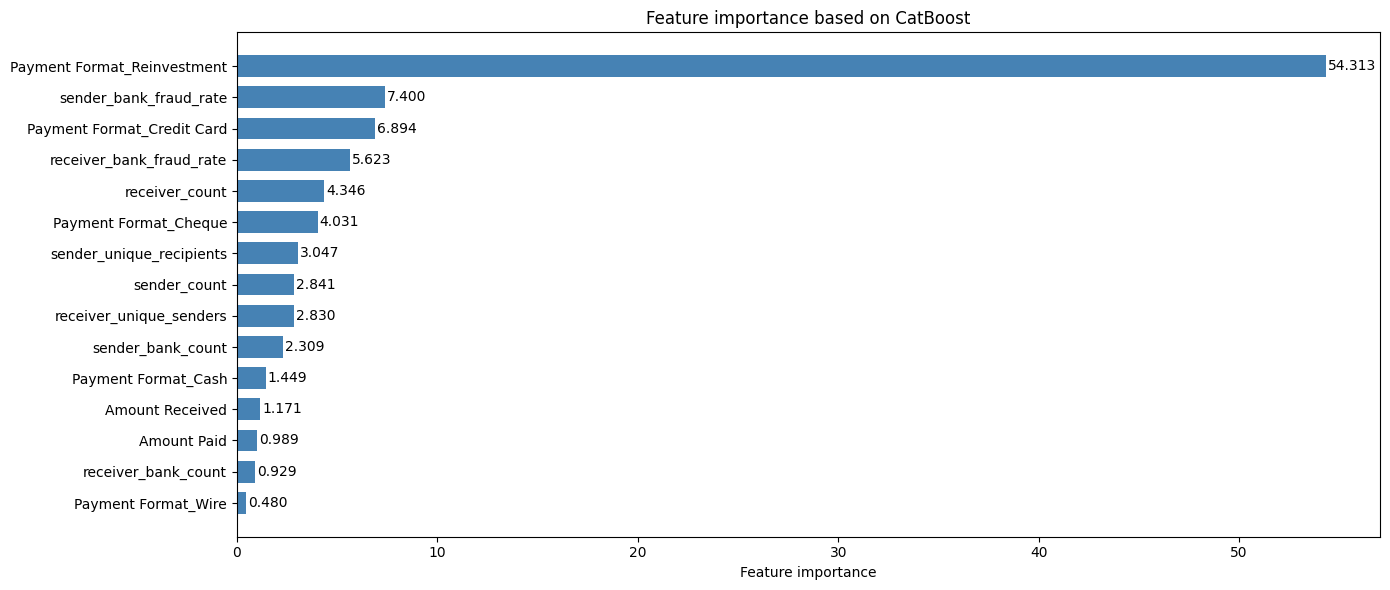

In [ ]:
# Визуализация feature importance для catboost
feature_importance = pd.Series( # используем pd.Series чтобы создать массив с названиями признаков и их важности для catboost
    cb.get_feature_importance(), # получаем самые важные признаки для CatBoost, которые больше всего влияли на решение
    index=X_train_scaled.columns # указываем названия признаков в качестве индексов
).sort_values(ascending=True).tail(15)  # сортируем и берем топ 15 признаков, которые были самыми важными

plt.figure(figsize=(14, 6))
bars = plt.barh(feature_importance.index, feature_importance.values, height=0.7, color='steelblue')
plt.title('Feature importance based on CatBoost')
plt.xlabel('Feature importance')

# добавляем подписи значений справа от полос
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.3f}', va='center')

plt.tight_layout()
plt.show()

Проверяем, почему catboost мог выбрать `Payment_Format_Reinvestment`, как самый важный

In [ ]:
print("Fraud rate по Payment Format:")
print(df.groupby('Payment Format')['Is Laundering'].mean().sort_values(ascending=False))
print("Transactions count in Reinvestment:")
print(df[df['Payment Format'] == 'Reinvestment']['Is Laundering'].value_counts())

Fraud rate по Payment Format:
Payment Format
Bitcoin         0.694561
ACH             0.343120
Cash            0.028971
Cheque          0.026202
Credit Card     0.017470
Reinvestment    0.000000
Wire            0.000000
Name: Is Laundering, dtype: float64
Transactions count in Reinvestment:
Is Laundering
0    210768
Name: count, dtype: int64


Reinvestment and Wire have a fraud rate of 0% – not a single fraudulent transaction. Therefore, CatBoost uses Payment Format_Reinvestment = 1 as an absolute indicator of legitimacy. If a transaction via Reinvestment is 100% not fraudulent, the model has learnt this and relies on this feature most heavily.

1. Payment Format_Reinvestment — an absolute marker of a legitimate transaction
2. sender_bank_fraud_rate — the criminal history of the sending bank
3. receiver_bank_fraud_rate — the criminal history of the receiving bank  
4. receiver_count / sender_count — account activity
5. Amount Paid / Amount Received — transaction amounts


## Isolation forest
This is an unsupervised task: we predict anomalies based on transaction isolation

The Isolation Forest has an issue with duplicate transactions: if we have a cash-to-bitcoin withdrawal, it won’t find anything. So first, we’ll check whether such transactions exist in our data at all

https://habr.com/ru/companies/otus/articles/881086/

In [ ]:
import pandas as pd

# Сколько транзакций на один аккаунт
account_counts = df.groupby('Account')['Timestamp'].count().describe()
print('Transactions count per account')
print(account_counts)

# Аккаунт с наибольшим числом транзакций
top_account = df.groupby('Account')['Timestamp'].count().idxmax()
print('The most active account values')
df[df['Account'] == top_account].sort_values('Timestamp')[['Timestamp', 'Amount Paid', 'Payment Format', 'Is Laundering']]

Transactions count per account
count    221283.000000
mean          1.354564
std           6.880724
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        2648.000000
Name: Timestamp, dtype: float64
The most active account values


,Timestamp,Amount Paid,Payment Format,Is Laundering
162455,2022-09-01 00:00:00,33647.60,Cash,0
255401,2022-09-01 00:00:00,82.60,Cheque,0
30239,2022-09-01 00:00:00,639.33,Credit Card,0
182698,2022-09-01 00:00:00,36448.30,Cash,0
257858,2022-09-01 00:00:00,1463.34,Cheque,0
...,...,...,...,...
94102,2022-09-10 13:51:00,24978.04,Credit Card,1
199047,2022-09-10 16:14:00,117.89,Cheque,1
119840,2022-09-10 18:57:00,177.91,Credit Card,1
127996,2022-09-10 19:22:00,1802.94,Cheque,1


In [ ]:
# Доля аккаунтов с более чем 5 транзакциями
repeat_accounts = (df.groupby('Account')['Timestamp'].count() > 5).mean()
print(f"Accounts with >5 transactions: {repeat_accounts:.1%}")

Accounts with >5 transactions: 0.7%


Here, mean = 1.354564, which means an average of 1–2 transactions per person. So we can definitely go with Isolation Forest and not worry about LSTM (Long Short-Term Memory), which would be used to track transactions (https://habr.com/ru/companies/wunderfund/articles/331310/)

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, roc_auc_score

contamination = y_train.mean()
print(f"Contamination: {contamination:.4f}")

if_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_features=0.5,
    random_state=67
)

# Isolation Forest — unsupervised, обучаем только на X без меток
if_model.fit(X_train_scaled)

# predict возвращает -1 (аномалия) и 1 (норма) — переводим в 0/1
y_pred_if = (if_model.predict(X_test_scaled) == -1).astype(int)

print(classification_report(y_test, y_pred_if, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, -if_model.decision_function(X_test_scaled)):.4f}")

Contamination: 0.0292
              precision    recall  f1-score   support

       Legit       0.97      0.98      0.97     58201
       Fraud       0.13      0.12      0.12      1748

    accuracy                           0.95     59949
   macro avg       0.55      0.55      0.55     59949
weighted avg       0.95      0.95      0.95     59949

ROC-AUC: 0.7668


## MLP Classifier (Multi-layer Perceptron)
***part for extra point***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import HalvingGridSearchCV, StratifiedKFold

# находим оптимальный параметр альфа (range взяли из документации)
# https://scikit-learn.ru/stable/modules/neural_networks_supervised.html#mlp-tips

param_grid = {
    'alpha': 10.0 ** -np.arange(1, 7),
    'hidden_layer_sizes': [(32,), (64,)]
    }
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=67)
# StratifiedKFold проверяет, чтобы в каждой выборке сохранялась наша доля классов (97/3)
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

# гиперпараметры — HalvingGridSearchCV (successive halving по сетке)

grid = HalvingGridSearchCV(
    MLPClassifier(
        max_iter=200,
        early_stopping=True, # если модель сойдется быстрее, чем за 200 итераций, то остановимся. ускоряем, как можем))
        # еще классно, что с этим параметром модель оставляет 10% обучающих данных на валидацию
        # и если несколько эпох подряд результат не улучшается, то останавливается досрочно. ну и от переобучения защищает
        random_state=67
    ),
    param_grid,
    scoring='recall',
    cv=cv,
    random_state=67,
    n_jobs=-1,
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'alpha': np.float64(1e-06), 'hidden_layer_sizes': (64,)}


Тюнинг чувствительности

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# тестим стандартный порог 0.5
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1] #тут уже базово создаем массив с вероятностями по фроду

print("Result with default threshold (0.5)")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

best_f1 = 0
best_threshold = 0.5

for threshold in np.arange(0.1, 0.9, 0.05): # ищем топ трешхолд, просто перебираем массивчик))
    y_pred_threshold = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nResult with best threshold:", best_threshold)
print("Best F1:", best_f1)

y_pred_final = (y_proba >= best_threshold).astype(int)
print("\nFinal model")
print(classification_report(y_test, y_pred_final))

# даже нейронки не справляются с мощью российского яндекса

Result with default threshold (0.5)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     58201
           1       0.83      0.78      0.81      1748

    accuracy                           0.99     59949
   macro avg       0.91      0.89      0.90     59949
weighted avg       0.99      0.99      0.99     59949

ROC-AUC: 0.9787160948228142

Result with best threshold: 0.40000000000000013
Best F1: 0.8093758825190625

Final model
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     58201
           1       0.80      0.82      0.81      1748

    accuracy                           0.99     59949
   macro avg       0.90      0.91      0.90     59949
weighted avg       0.99      0.99      0.99     59949



# Final Comparison

                     Precision  Recall      F1  ROC-AUC
Model                                                  
Logistic Regression     0.2919  0.9228  0.4435   0.9772
KNN                     0.6344  0.8330  0.7203   0.9328
Isolation Forest        0.1273  0.1213  0.1242   0.7668
Decision Tree           0.4063  0.9062  0.5610   0.9448
Random Forest           0.5521  0.9182  0.6896   0.9931
CatBoost                0.6131  0.9382  0.7416   0.9958
MLP                     0.7992  0.8198  0.8094   0.9787


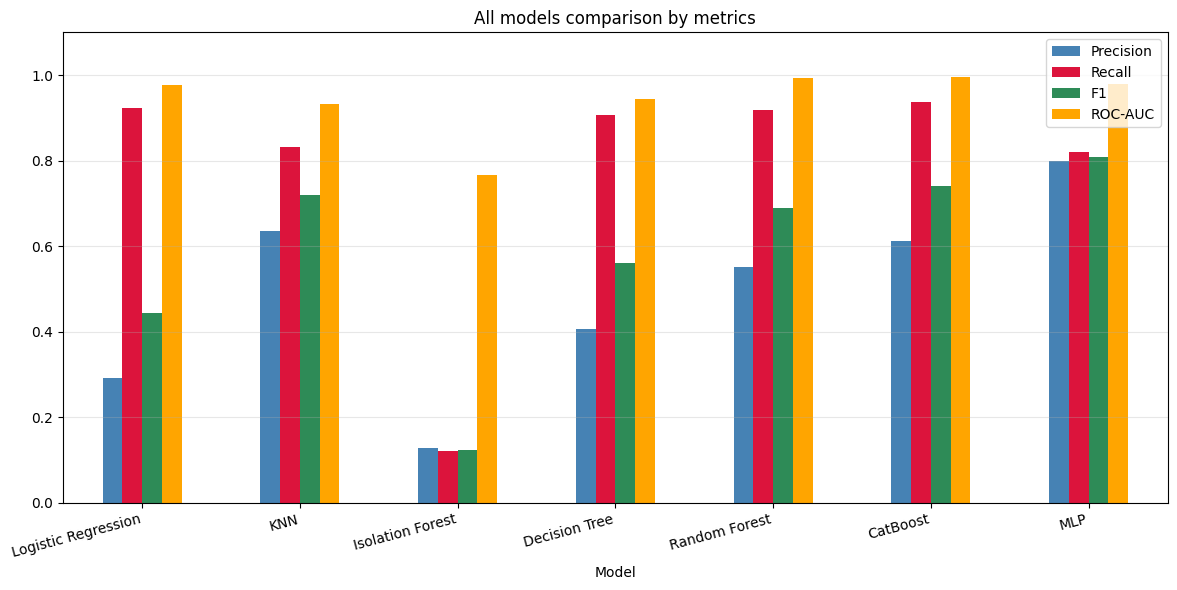

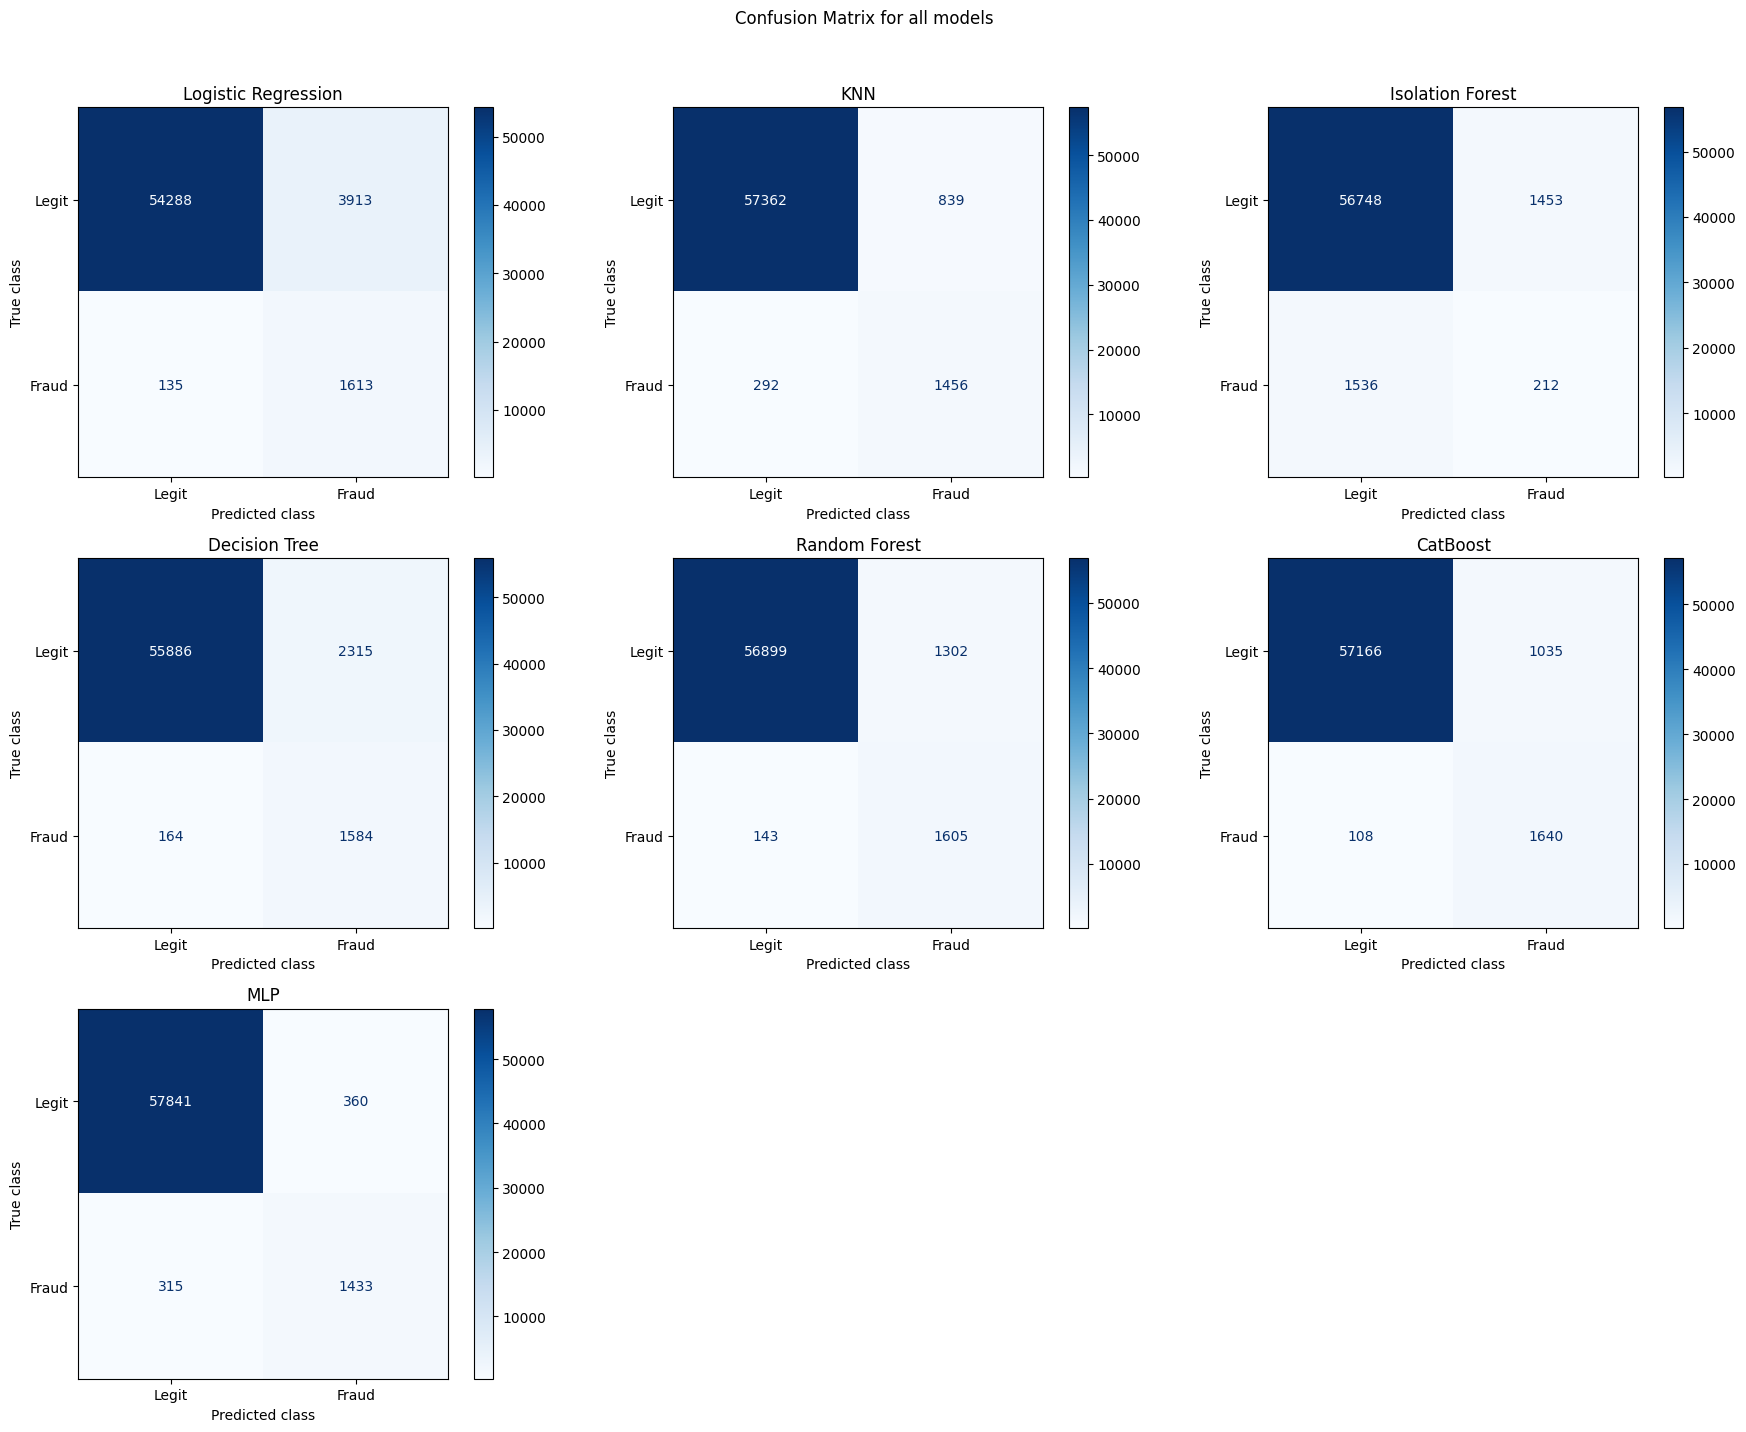

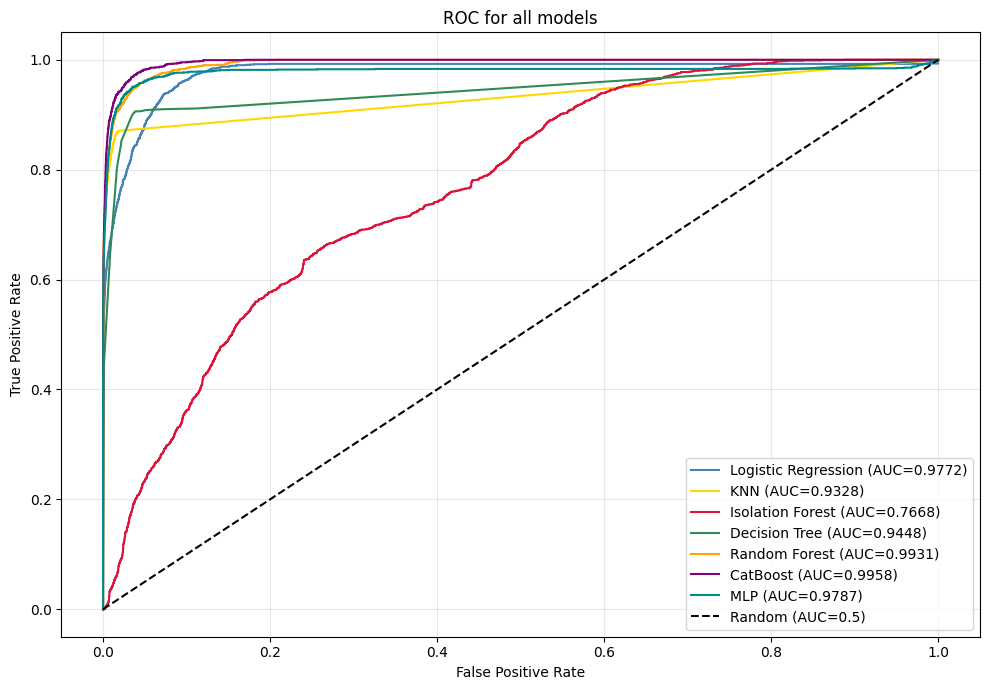

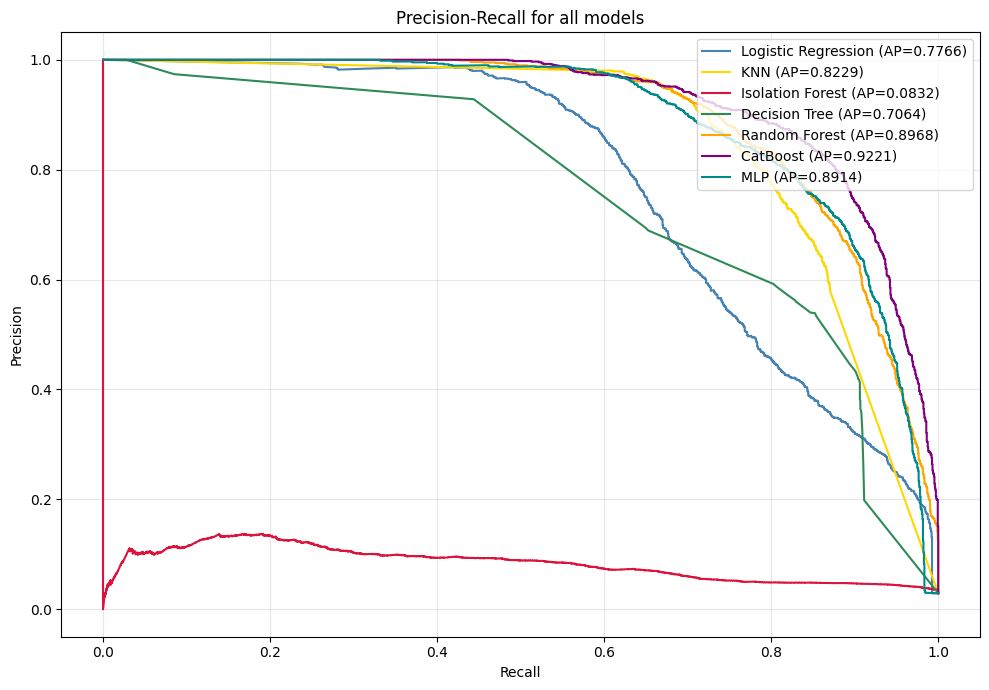

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# Данные для всех моделей
models = {
    'Logistic Regression': (y_pred_lr , lr.predict_proba(X_test_scaled)[:, 1]),
    'KNN' : (y_pred_knn, best_knn.predict_proba(X_test_scaled)[:, 1]),
    'Isolation Forest': (y_pred_if,-if_model.decision_function(X_test_scaled)),
    'Decision Tree': (y_pred_dt,dt.predict_proba(X_test_scaled)[:, 1]),
    'Random Forest': (y_pred_rf, rf.predict_proba(X_test_scaled)[:, 1]),
    'CatBoost' :(y_pred_cb, cb.predict_proba(X_test_scaled)[:, 1]),
    'MLP': (y_pred_final, best_model.predict_proba(X_test_scaled)[:, 1]),
}


# Таблица для сравнения всех можелей
results = []
for name, (y_pred, y_proba) in models.items():
    results.append({
        'Model': name,
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC':roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

# График со сравнением всех метрик
results_df[['Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(12, 6),
    color=['steelblue', 'crimson', 'seagreen', 'orange']
)
plt.title('All models comparison by metrics')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix для каждой модели
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (name, (y_pred,_)) in enumerate(models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Legit', 'Fraud'],
        cmap='Blues',
        ax=axes[i]
    )
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted class')
    axes[i].set_ylabel('True class')

for j in range(len(models), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Confusion Matrix for all models', y=1.02)
plt.tight_layout()
plt.show()

# ROC для каждой модели
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'gold', 'crimson', 'seagreen', 'orange', 'purple', 'darkcyan']

for (name, (_, y_proba)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC for all models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision-Recall для каждой модели
plt.figure(figsize=(10, 7))

for (name, (_, y_proba)), color in zip(models.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.4f})', color=color)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall for all models')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299742 entries, 0 to 299741
Data columns (total 51 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Amount Received                     299742 non-null  float64
 1   Amount Paid                         299742 non-null  float64
 2   Is Laundering                       299742 non-null  int64  
 3   sender_bank_fraud_rate              299742 non-null  float64
 4   sender_bank_count                   299742 non-null  float64
 5   receiver_bank_fraud_rate            299742 non-null  float64
 6   receiver_bank_count                 299742 non-null  float64
 7   sender_count                        299742 non-null  int64  
 8   sender_avg_amount                   299742 non-null  float64
 9   sender_unique_recipients            299742 non-null  int64  
 10  receiver_count                      299742 non-null  int64  
 11  receiver_avg_amount       

As a conclusion of ourproject, we conducted a comparative evaluation of four machine learning architectures for the task of anti-money laundering (AML) detection. **Recall** (the ability to minimize the number of missed criminal transactions) was selected as the primary performance metric, in combination with ROC-AUC (the model’s overall discriminatory power).

1) Among all the models, the CatBoost model demonstrated the best performance, achieving the highest F1-score and recall. This is due to the nature of the data: financial transactions have a complex structure of categorical features and nonlinear dependencies, which gradient boosting handles more effectively than classical ensembles or linear models.

2) We also outlined the importance of threshold optimization. Testing of the neural network (MLP) and CatBoost demonstrated that the standard classification threshold (0.5) is not optimal for anti-fraud systems. **Lowering the threshold to 0.4 significantly increased recall (by an average of 4-5%)**, which is critical for minimizing the bank’s financial and reputational risks associated with missing fraudulent transactions.

3) Last but not least, **feature importance tools** (specifically in CatBoost) confirmed that the most informative features are transaction amount (on a logarithmic scale), entity type, and bank ID (From Bank). This supports the hypothesis of the existence of persistent “criminal nodes” within the banking network.

For deployment in a production environment, we recommend using the CatBoost model with an optimized probability threshold. It provides the best protection against false negatives (missed money laundering cases) while maintaining an acceptable level of false positives, thereby minimizing the number of unjustified blocks of legitimate customers.